<a href="https://colab.research.google.com/github/heeseok00/project_DScover_Price_Prediction/blob/main/DScover_%EB%86%8D%EC%82%B0%EB%AC%BC_%EB%AC%BC%EA%B0%80%EC%98%88%EC%B8%A1_%EA%B2%BD%EC%A7%84%EB%8C%80%ED%9A%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. 환경 설정

In [121]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [122]:
# 작업 경로 설정
import os

project_path = "/content/drive/MyDrive/0. 포트폴리오/프로젝트/[260224-261231] SKKU_DScover_학회/가이드프로젝트"

os.chdir(project_path)

print("현재 작업 경로:", os.getcwd())

현재 작업 경로: /content/drive/MyDrive/0. 포트폴리오/프로젝트/[260224-261231] SKKU_DScover_학회/가이드프로젝트


In [123]:
# 파일 제대로 보이는지 확인
os.listdir()

['sample_submission.csv', 'train', 'fonts', 'test']

In [124]:
# train 폴더 내부 파일 구조 확인
os.listdir("train")

['train.csv', 'meta']

In [125]:
# train/meta 폴더 내부 파일 구조 확인
os.listdir("train/meta")

['TRAIN_산지공판장_2018-2021.csv', 'TRAIN_전국도매_2018-2021.csv']

In [126]:
# test 폴더 내부 파일 구조 확인
os.listdir("test")

['TEST_09.csv',
 'TEST_14.csv',
 'TEST_00.csv',
 'TEST_13.csv',
 'TEST_04.csv',
 'meta',
 'TEST_03.csv',
 'TEST_08.csv',
 'TEST_11.csv',
 'TEST_06.csv',
 'TEST_01.csv',
 'TEST_02.csv',
 'TEST_16.csv',
 'TEST_20.csv',
 'TEST_07.csv',
 'TEST_17.csv',
 'TEST_21.csv',
 'TEST_23.csv',
 'TEST_19.csv',
 'TEST_15.csv',
 'TEST_24.csv',
 'TEST_05.csv',
 'TEST_12.csv',
 'TEST_10.csv',
 'TEST_22.csv',
 'TEST_18.csv']

In [127]:
# test/meta 폴더 내부 파일 구조 확인
os.listdir("test/meta")

['TEST_전국도매_03.csv',
 'TEST_전국도매_13.csv',
 'TEST_산지공판장_12.csv',
 'TEST_산지공판장_07.csv',
 'TEST_전국도매_06.csv',
 'TEST_전국도매_09.csv',
 'TEST_전국도매_00.csv',
 'TEST_산지공판장_01.csv',
 'TEST_산지공판장_04.csv',
 'TEST_산지공판장_08.csv',
 'TEST_전국도매_07.csv',
 'TEST_산지공판장_10.csv',
 'TEST_전국도매_04.csv',
 'TEST_산지공판장_03.csv',
 'TEST_산지공판장_22.csv',
 'TEST_전국도매_08.csv',
 'TEST_산지공판장_23.csv',
 'TEST_산지공판장_02.csv',
 'TEST_산지공판장_13.csv',
 'TEST_산지공판장_11.csv',
 'TEST_산지공판장_15.csv',
 'TEST_산지공판장_21.csv',
 'TEST_산지공판장_14.csv',
 'TEST_산지공판장_16.csv',
 'TEST_산지공판장_17.csv',
 'TEST_산지공판장_18.csv',
 'TEST_산지공판장_24.csv',
 'TEST_산지공판장_20.csv',
 'TEST_산지공판장_19.csv',
 'TEST_산지공판장_09.csv',
 'TEST_산지공판장_00.csv',
 'TEST_산지공판장_05.csv',
 'TEST_산지공판장_06.csv',
 'TEST_저

In [128]:
# font 폴더 내부 파일 구조 확인
os.listdir("fonts")

['NanumGothic-ExtraBold.ttf',
 'NanumGothic-Regular.ttf',
 'NanumGothic-Bold.ttf',
 'OFL.txt']

In [129]:
# 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "fonts/NanumGothic-Regular.ttf"

# 폰트 등록
fm.fontManager.addfont(font_path)

# 캐시 재로드
fm._load_fontmanager(try_read_cache=False)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

sns.set(font=font_name)

print("적용된 폰트:", font_name)

적용된 폰트: NanumGothic


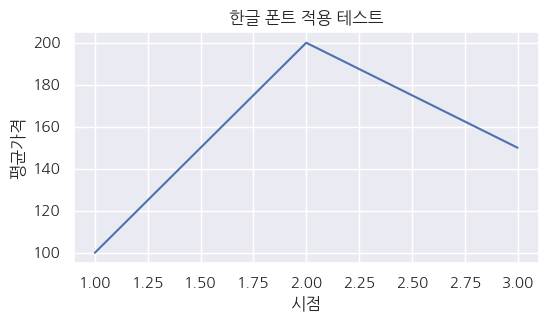

In [130]:
# 폰트 설정 테스트
plt.figure(figsize=(6,3))

plt.title("한글 폰트 적용 테스트")
plt.xlabel("시점")
plt.ylabel("평균가격")

plt.plot([1,2,3],[100,200,150])

plt.show()

# 1. Train Data 확인

In [131]:
# train 데이터 3개 읽어봐서 형태 확인
import pandas as pd

main_df = pd.read_csv("train/train.csv")

wholesale_df = pd.read_csv(
    "train/meta/TRAIN_전국도매_2018-2021.csv"
)

auction_














df = pd.read_csv(
    "train/meta/TRAIN_산지공판장_2018-2021.csv"
)

print(main_df.shape)
print(wholesale_df.shape)
print(auction_df.shape)

(29376, 7)
(176014, 22)
(118628, 21)


In [132]:
# train 데이터 3개 기본 구조 확인

print("main")
display(main_df.head())

print("wholesale")
display(wholesale_df.head())

print("auction")
display(auction_df.head())

main


,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,"381,666.67","590,000.00"
1,201801중순,건고추,화건,30 kg,상품,"380,809.67","590,000.00"
2,201801하순,건고추,화건,30 kg,상품,"380,000.00","590,000.00"
3,201802상순,건고추,화건,30 kg,상품,"380,000.00","590,000.00"
4,201802중순,건고추,화건,30 kg,상품,"376,666.67","590,000.00"


wholesale


,시점,시장코드,시장명,품목코드,품목명,품종코드,품종명,총반입량(kg),총거래금액(원),평균가(원/kg),고가(20%) 평균가,중가(60%) 평균가,저가(20%) 평균가,중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도
0,201801상순,100000,*전국도매시장,501,감자,50124,깐감자,20.00,86520,"4,326.00",0.00,0.00,"4,326.00","4,326.00","4,326.00","4,326.00",1,0.00,"4,009.00",0.00,0.00,2018
1,201801상순,100000,*전국도매시장,501,감자,50121,돼지감자,"12,380.00",11650810,941.10,"1,350.73",944.47,545.11,"1,010.00",200.00,"3,000.00",117,"11,213.36","9,174.20","8,167.90",0.00,2018
2,201801상순,100000,*전국도매시장,501,감자,50110,자주감자,240.00,158400,660.00,"1,000.00",656.00,500.00,550.00,500.00,"1,000.00",7,"12,553.28","12,612.22","24,990.32","18,483.96",2018
3,201801상순,100000,*전국도매시장,501,감자,50111,가을감자,10.00,37500,"3,750.00",0.00,"3,800.00","3,700.00","3,750.00","3,700.00","3,800.00",2,"24,929.46","40,365.08",0.00,0.00,2018
4,201801상순,100000,*전국도매시장,501,감자,50199,기타감자,"1,367,301.30",2403199462,"1,757.62","2,351.36","1,831.95",955.29,"1,360.45",0.00,"10,581.08",872,"30,806.78","27,661.15","23,741.95","19,340.12",2018


auction


,시점,공판장코드,공판장명,품목코드,품목명,품종코드,품종명,등급코드,등급명,총반입량(kg),총거래금액(원),평균가(원/kg),중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도
0,201801상순,1000000000,*전국농협공판장,501,감자,50101,수미,11,특,"15,470.00",26494500,"1,712.64","1,723.96","1,545.45","2,320.67",7,"1,947.35","1,769.86","1,023.98",0.00,2018
1,201801상순,1000000000,*전국농협공판장,501,감자,50101,수미,12,상,"2,900.00",3476100,"1,198.66","1,252.74",893.06,"1,417.86",4,"1,301.24","1,348.25",571.31,0.00,2018
2,201801상순,1000000000,*전국농협공판장,501,감자,50199,기타감자,13,보통,"1,320.00",811800,615.00,600.00,240.00,911.88,7,630.85,449.17,473.03,0.00,2018
3,201801상순,1000000000,*전국농협공판장,501,감자,50199,기타감자,12,상,460.00,250300,544.13,365.00,200.00,"1,650.00",5,"1,088.05","1,129.60",734.02,0.00,2018
4,201801상순,1000000000,*전국농협공판장,501,감자,50199,기타감자,11,특,"30,967.00",58108166,"1,876.45","2,010.44","1,598.33","2,438.72",8,"2,126.40","1,779.26","1,750.54",0.00,2018


In [133]:
# 품목명 기본 분포 확인
main_df["품목명"].value_counts()

,count
품목명,
양파,9792
감자,4752
무,4752
배추,3744
대파,3024
건고추,1152
사과,720
배,576
상추,576


In [134]:
# 품종명 기본 분포 확인
main_df["품종명"].value_counts()

,count
품종명,
양파,2880
다발무,2736
저장양파,1728
자주양파,1728
양파(햇),1728
쌈배추,1152
대파(일반),1152
무,1152
조생양파,1152


In [135]:
# 시점 기본 분포 확인
main_df["시점"].value_counts()

,count
시점,
201801상순,204
201801중순,204
201801하순,204
201802상순,204
201802중순,204
201802하순,204
201803상순,204
201803중순,204
201803하순,204


In [136]:
# 시점 Parsing
# 예를 들면 '201801상순' -> year, month, 순 으로 분리

In [137]:
# train.csv에서 0을 결측치로 변경 (이 데이터에서 0이 사실상 결측치이니까)
import numpy as np

main_df['평균가격(원)'] = main_df['평균가격(원)'].replace(0, np.nan)

main_df['평년 평균가격(원)'] = main_df['평년 평균가격(원)'].replace(0, np.nan)

In [138]:
# 결측치 확인
main_df.isnull().sum()

,0
시점,0
품목명,0
품종명,0
거래단위,0
등급,0
평년 평균가격(원),21860
평균가격(원),12713


In [139]:
# main_df 결측치 처리 (나중에 수정 필요)

import numpy as np

# 0을 NaN으로 변환
main_df['평균가격(원)'] = main_df['평균가격(원)'].replace(0, np.nan)
main_df['평년 평균가격(원)'] = main_df['평년 평균가격(원)'].replace(0, np.nan)

# target 없는 행 제거 + copy
main_df = main_df.dropna(subset=['평균가격(원)']).copy()
# 1) 품목명+품종명 기준으로 채우기
main_df['평년 평균가격(원)'] = main_df['평년 평균가격(원)'].fillna(
    main_df.groupby(['품목명', '품종명'])['평년 평균가격(원)'].transform('mean')
)

# 2) 품목명 기준으로 채우기
main_df['평년 평균가격(원)'] = main_df['평년 평균가격(원)'].fillna(
    main_df.groupby('품목명')['평년 평균가격(원)'].transform('mean')
)

# 3) 그래도 남으면 전체 중앙값으로 채우기
main_df['평년 평균가격(원)'] = main_df['평년 평균가격(원)'].fillna(
    main_df['평년 평균가격(원)'].median()
)

# 확인
print(main_df.isnull().sum())

시점            0
품목명           0
품종명           0
거래단위          0
등급            0
평년 평균가격(원)    0
평균가격(원)       0
dtype: int64


In [146]:
# 시점 파싱

def parse_time_simple(x):
    x = str(x).strip()

    year = int(x[:4])      # 예: 2018
    month = int(x[4:6])    # 예: 01 -> 1
    soon_text = x[6:]      # 상순 / 중순 / 하순

    soon_map = {
        "상순": 1,
        "중순": 2,
        "하순": 3
    }
    soon_num = soon_map[soon_text]

    return pd.Series([year, month, soon_text, soon_num])

main_df[["연도", "월", "순텍스트", "순번호"]] = main_df["시점"].apply(parse_time_simple)

display(main_df[["시점", "연도", "월", "순텍스트", "순번호"]].head(10))

,시점,연도,월,순텍스트,순번호
0,201801상순,2018,1,상순,1
1,201801중순,2018,1,중순,2
2,201801하순,2018,1,하순,3
3,201802상순,2018,2,상순,1
4,201802중순,2018,2,중순,2
5,201802하순,2018,2,하순,3
6,201803상순,2018,3,상순,1
7,201803중순,2018,3,중순,2
8,201803하순,2018,3,하순,3
9,201804상순,2018,4,상순,1


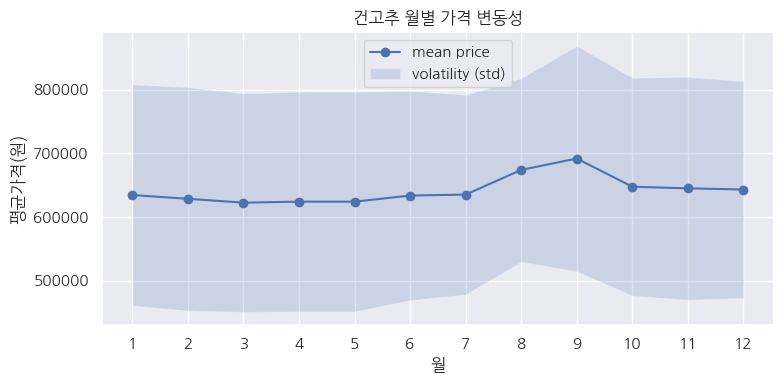

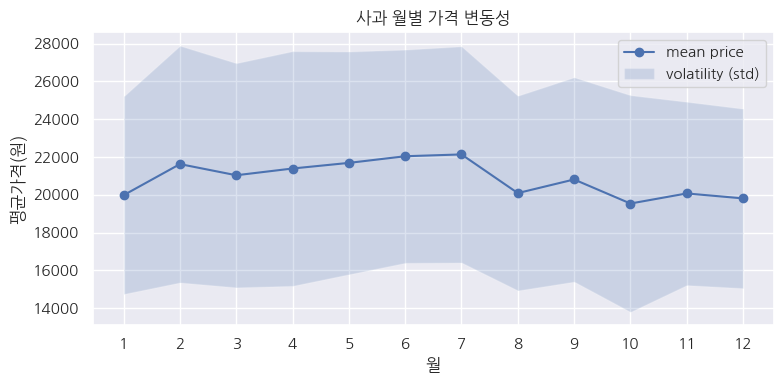

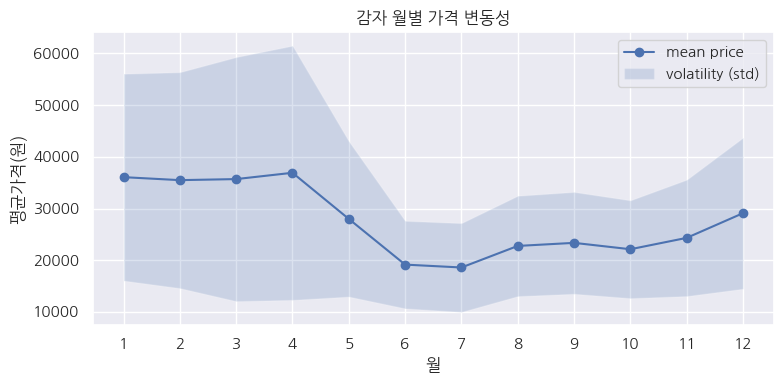

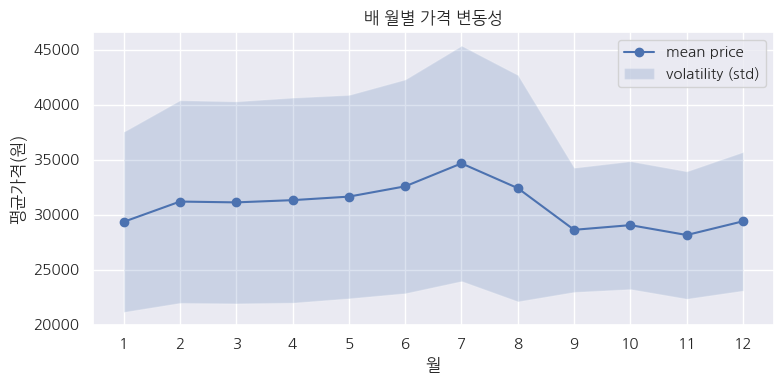

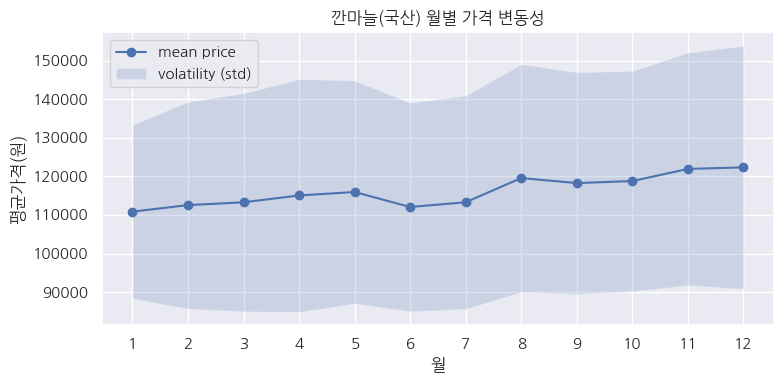

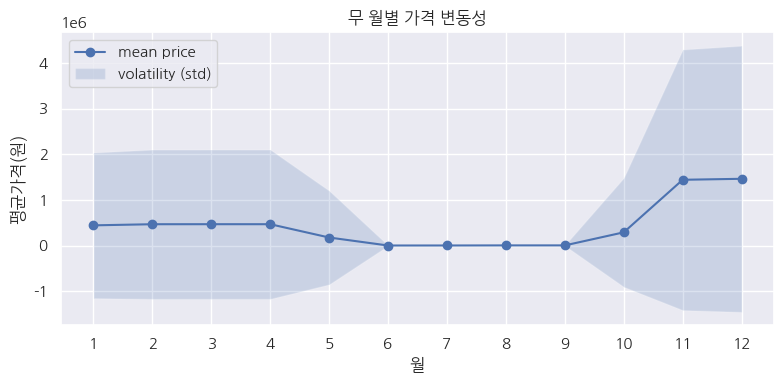

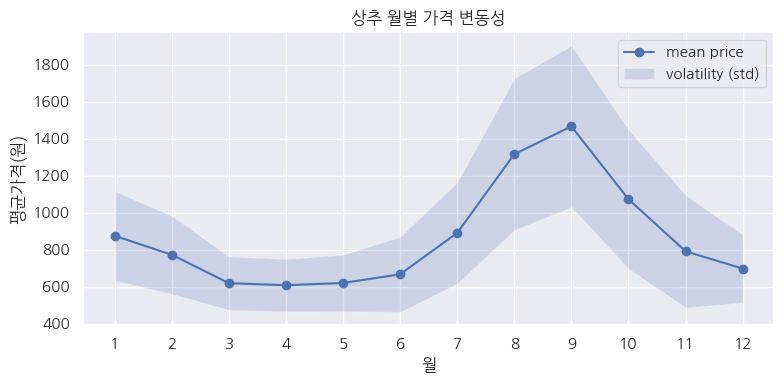

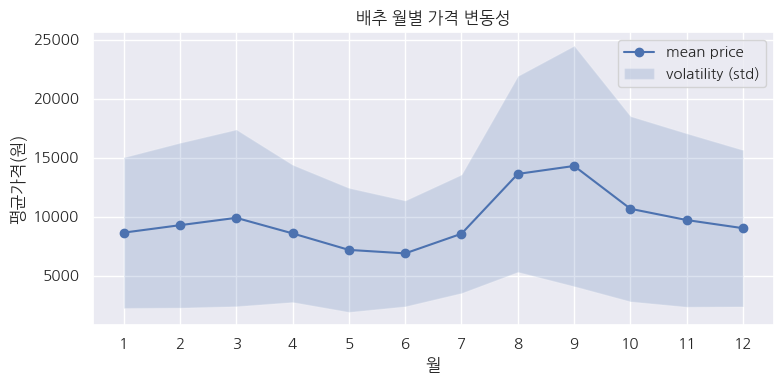

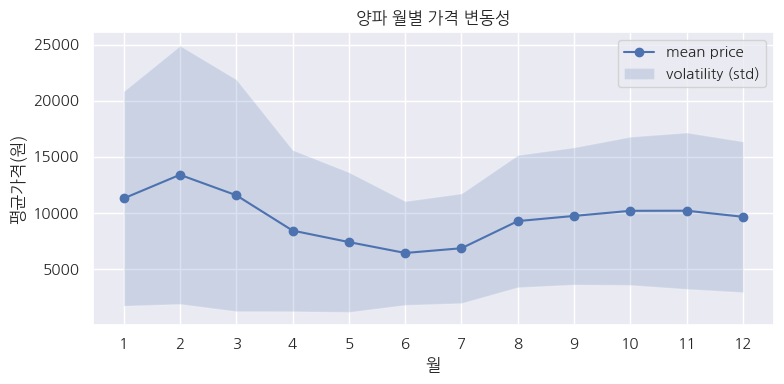

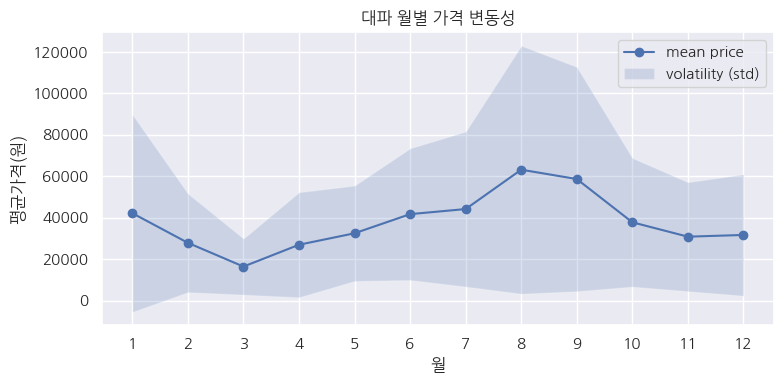

In [153]:
# 품복별 월별 가격 변동
import matplotlib.pyplot as plt
import seaborn as sns

items = main_df["품목명"].unique()

for item in items:

    temp = main_df[main_df["품목명"] == item]

    month_stats = (
        temp.groupby("월")["평균가격(원)"]
        .agg(["mean","std"])
        .reset_index()
    )

    plt.figure(figsize=(8,4))

    # 평균선
    plt.plot(
        month_stats["월"],
        month_stats["mean"],
        marker="o",
        label="mean price"
    )

    # 변동성 영역 (std)
    plt.fill_between(
        month_stats["월"],
        month_stats["mean"] - month_stats["std"],
        month_stats["mean"] + month_stats["std"],
        alpha=0.2,
        label="volatility (std)"
    )

    plt.title(f"{item} 월별 가격 변동성")
    plt.xlabel("월")
    plt.ylabel("평균가격(원)")

    plt.xticks(range(1,13))

    plt.legend()

    plt.tight_layout()

    plt.show()


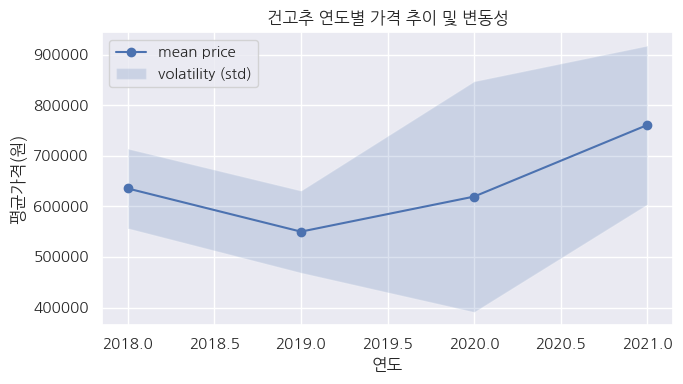

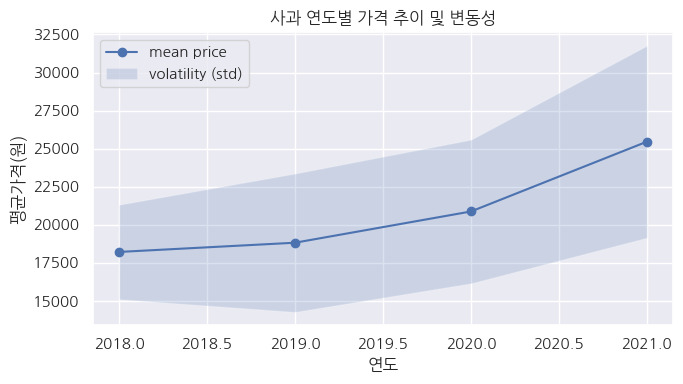

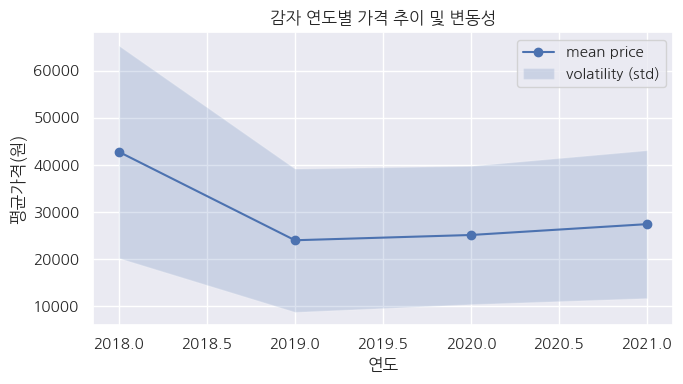

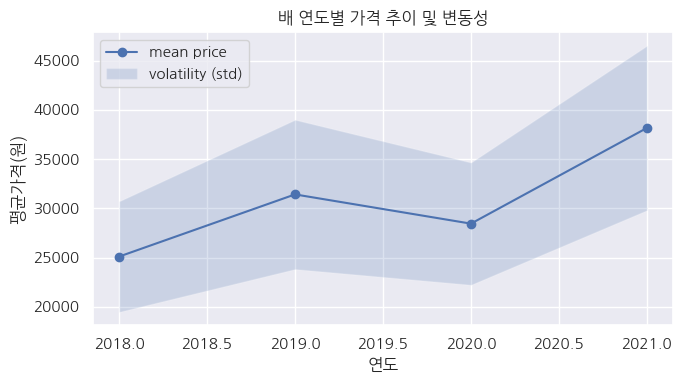

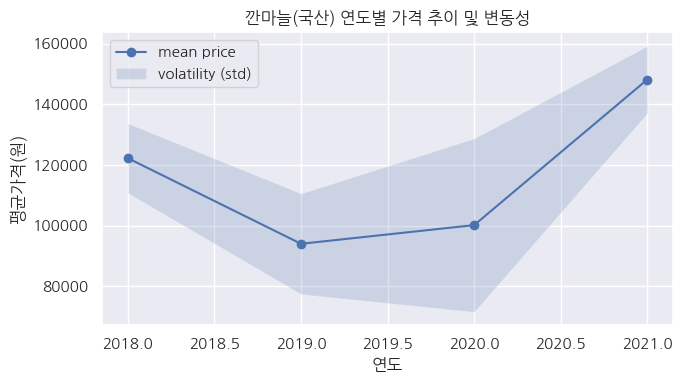

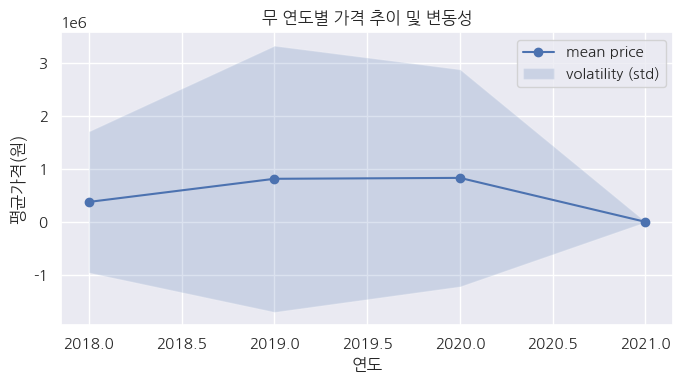

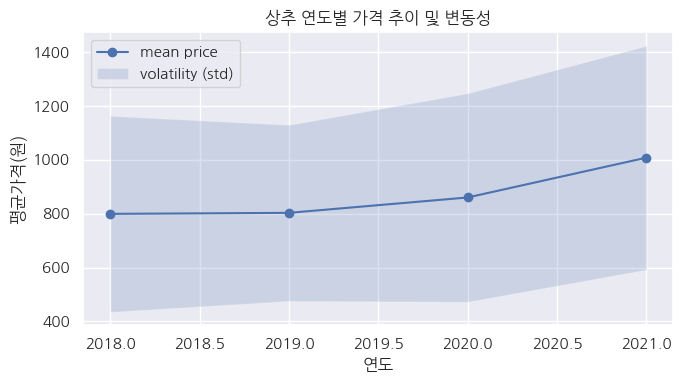

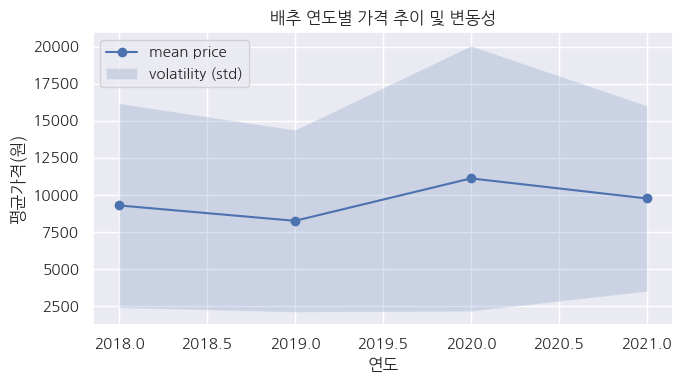

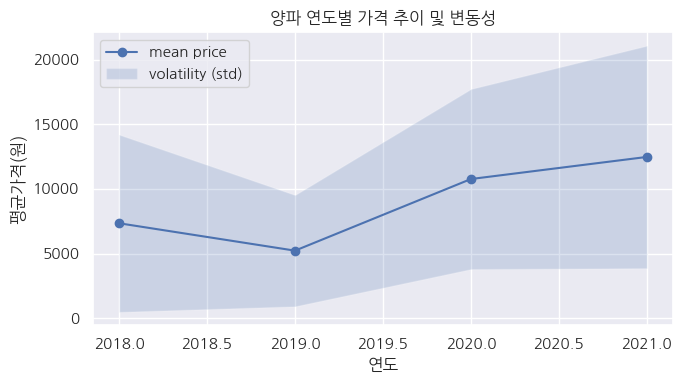

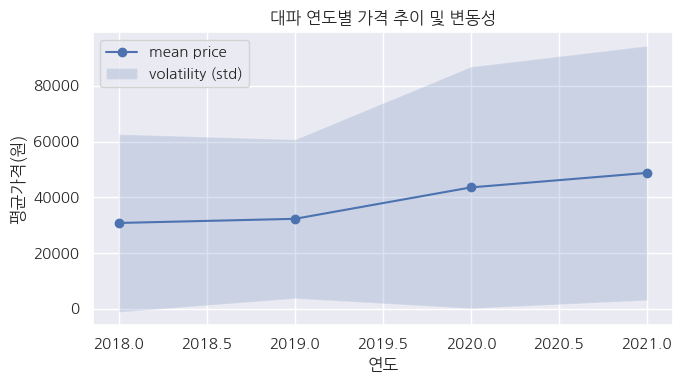

In [154]:
# 품복별 연별 가격 변동
import matplotlib.pyplot as plt

items = main_df["품목명"].unique()

for item in items:

    temp = main_df[main_df["품목명"] == item]

    year_stats = (
        temp.groupby("연도")["평균가격(원)"]
        .agg(["mean","std"])
        .reset_index()
    )

    plt.figure(figsize=(7,4))

    # 평균 가격 추이
    plt.plot(
        year_stats["연도"],
        year_stats["mean"],
        marker="o",
        label="mean price"
    )

    # 변동성 영역
    plt.fill_between(
        year_stats["연도"],
        year_stats["mean"] - year_stats["std"],
        year_stats["mean"] + year_stats["std"],
        alpha=0.2,
        label="volatility (std)"
    )

    plt.title(f"{item} 연도별 가격 추이 및 변동성")
    plt.xlabel("연도")
    plt.ylabel("평균가격(원)")

    plt.legend()

    plt.tight_layout()

    plt.show()